In [2]:
# importing all the required dependencies
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE # to handle imbalanced
# ml algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, f1_score, recall_score
from sklearn.model_selection import StratifiedKFold
import pickle # to save the model
import shap
# to ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv('../data/ml_data.csv')
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,Yes
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer,42.30,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,Yes


In [4]:
data.shape

(7016, 19)

In [5]:
data.duplicated().sum()

np.int64(0)

In [6]:
# separating features and target
features = data.drop(columns='Churn')
target = data[['Churn']]

# spliting train and test set
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state= 63, stratify=target)

In [7]:
y_train.value_counts(normalize=True)

Churn
No       0.735388
Yes      0.264612
Name: proportion, dtype: float64

- The dataset is imbalanced. 

In [8]:
data.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'Churn'],
      dtype='object')

In [9]:
# initializing a dictionary to store the encoder and column
encoders = {}
# List of columns to which label encoding was applied
label_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies','PaperlessBilling','PaymentMethod', 'Contract']

In [10]:
# label encoding

for col in label_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    encoders[col] = le

In [11]:
# mapping the target feature into numeric 
y_train['Churn'] = y_train['Churn'].map({'No':0, 'Yes':1})
y_test['Churn'] = y_test['Churn'].map({'No':0, 'Yes':1})

In [12]:
# saving the encoders 
encoder_name = '../models/encoder.pkl'
with open(encoder_name, 'wb') as f:
    pickle.dump(encoders, f)

In [13]:
X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges
19,0,0,0,0,21,1,0,1,0,1,1,0,0,1,0,1,2,90.05
3958,0,0,1,0,72,1,0,2,0,0,0,0,0,0,2,0,0,20.05
5563,0,0,1,1,70,1,1,1,1,1,1,1,0,0,2,0,0,93.90
6189,1,1,0,0,46,1,0,1,1,0,0,0,0,1,0,0,2,85.00
262,1,1,1,0,57,1,1,1,0,1,0,0,0,1,0,1,2,89.85


- Stratified K-Fold Cross-Validation is used to evaluate the performance of different machine learning models. 

- To balance classes, an over-sampling technique called SMOTE is used with a sampling strategy of 0.5, so the minority class will reach half of the majority class.
- Class imbalanced ratio is = (1: 2.77).

In [14]:
# models to train
models = {
    'Logistic Regression' : LogisticRegression(random_state=63),
    'Decision Tree' : DecisionTreeClassifier(random_state=56),
    'Random For' : RandomForestClassifier( random_state=63),
    'Xgboost' : xgb.XGBClassifier(random_state= 42),
    'Gradient Boost' : GradientBoostingClassifier(random_state=42)
}

In [15]:
# Stratified k-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=43)

# SMOTE oversampling technique
sm = SMOTE(sampling_strategy=0.5, random_state=42)

In [16]:
model_results = {model_name: {'accuracy': [], 'precision': [], 'recall': []}
                 for model_name in models.keys()}

In [17]:
# iterate through each model, train them and store their avg accuracy, avg precision and avg recall
for train_index, val_index in skf.split(X_train, y_train):
    train_x, val_x = X_train.iloc[train_index], X_train.iloc[val_index]
    train_y, val_y = y_train.iloc[train_index], y_train.iloc[val_index]


    train__x_res, train_y__res = sm.fit_resample(train_x, train_y) # smote sampling

    for model_name, model in models.items():
        model.fit(train__x_res, train_y__res)
        y_pred = model.predict(val_x)
        
        acc = accuracy_score(val_y, y_pred)
        prec = precision_score(val_y, y_pred)
        rec = recall_score(val_y, y_pred)

        model_results[model_name]['accuracy'].append(acc)
        model_results[model_name]['precision'].append(prec)
        model_results[model_name]['recall'].append(rec)

In [18]:
final_averages = []

for model_name, metrics in model_results.items():
  final_averages.append({
        'Model': model_name,
        'Mean Accuracy': np.mean(metrics['accuracy']),
        'Mean Precision': np.mean(metrics['precision']),
        'Mean Recall': np.mean(metrics['recall'])
    })

In [19]:
result_df = pd.DataFrame(final_averages)
result_df.sort_values(by='Mean Recall', ascending=False)

,Model,Mean Accuracy,Mean Precision,Mean Recall
0,Logistic Regression,0.791338,0.603700,0.617508
4,Gradient Boost,0.789557,0.604675,0.591919
3,Xgboost,0.777083,0.584866,0.542088
2,Random For,0.783319,0.602998,0.532660
1,Decision Tree,0.736281,0.502091,0.522559


- The primary goal is to identify customers who are likely to churn, so false negatives are given more importance than false positives.
- The Logistic Regression algorithm performs better than the other algorithms in terms of recall, so it is selected as the final model.

In [20]:
# Logistic Regression
model_lr = LogisticRegression(C=1.0, penalty='l2', solver='lbfgs', random_state=63)

# SMOTE
X_train_res, y_train_res = sm.fit_resample(X_train, y_train) 

print(y_train.value_counts())
print(y_train_res.value_counts())

Churn
0        4127
1        1485
Name: count, dtype: int64
Churn
0        4127
1        2063
Name: count, dtype: int64


In [21]:
model_lr.fit(X_train_res, y_train_res)
y_pred = model_lr.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1032
           1       0.58      0.63      0.60       372

    accuracy                           0.78      1404
   macro avg       0.72      0.73      0.73      1404
weighted avg       0.79      0.78      0.79      1404



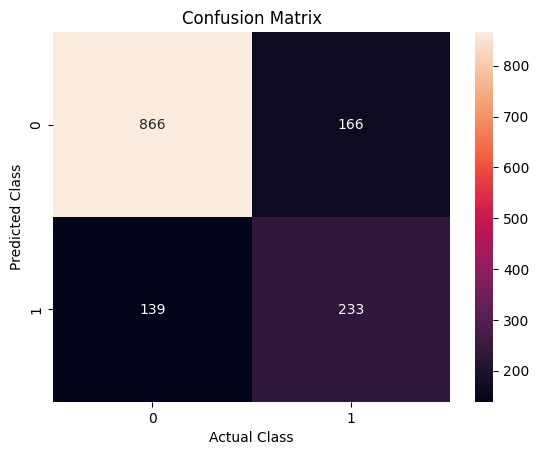

In [22]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='.0f')
plt.title("Confusion Matrix")
plt.xlabel('Actual Class')
plt.ylabel("Predicted Class")
plt.show()

In [23]:
# save the logistic regression model
filename = '../models/logistic_reg.pkl'
with open(filename, 'wb') as f:
    pickle.dump(model_lr, f)

### SHAP Values

In [24]:
masker = shap.maskers.Independent(X_train, max_samples=6000)
explainer = shap.LinearExplainer(model = model_lr, masker=masker)
shap_values = explainer(X_test)

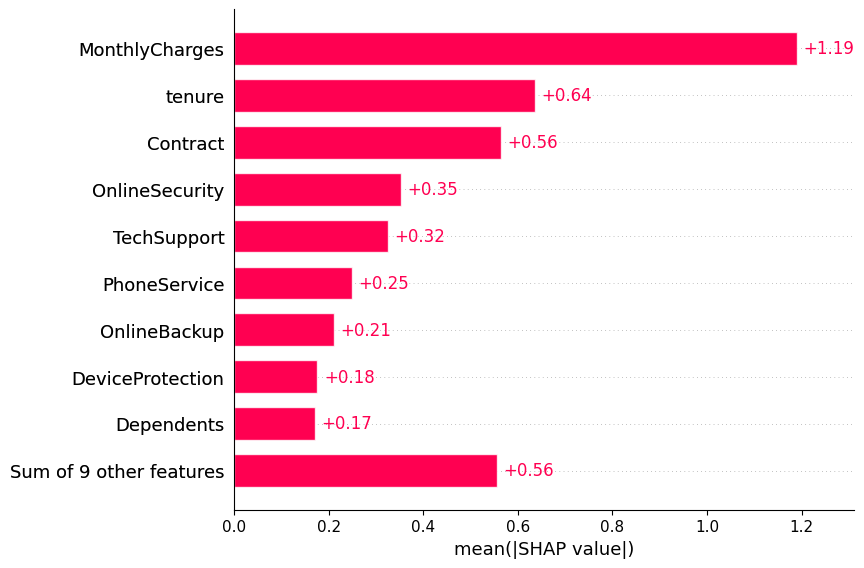

In [25]:
shap.plots.bar(shap_values)

- Bar plot shows how much each variable affects the model in absolute terms. 

- The prediction score is highly affected by `MonthlyCharges`, followed by `tenure` and `Contract`.

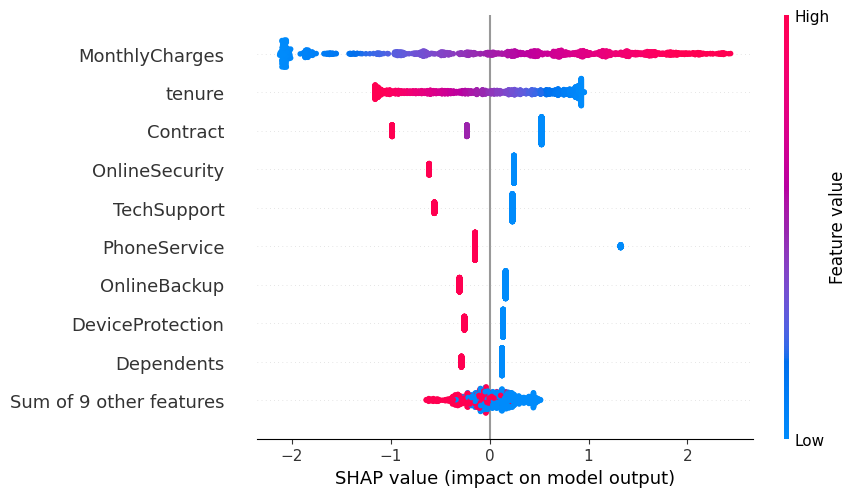

In [26]:
shap.plots.beeswarm(shap_values)

- Red represents a high value for that feature, while blue represents a low value.
- Points to the right of the center line (positive values) push the prediction score up. Points to the left of the center line (negative values) push the prediction score down. 

- High monthly charges increase the prediction value, while low monthly charges decrease the prediction value. 
- A low tenure increases the prediction value, while a high tenure decreases the prediction value.

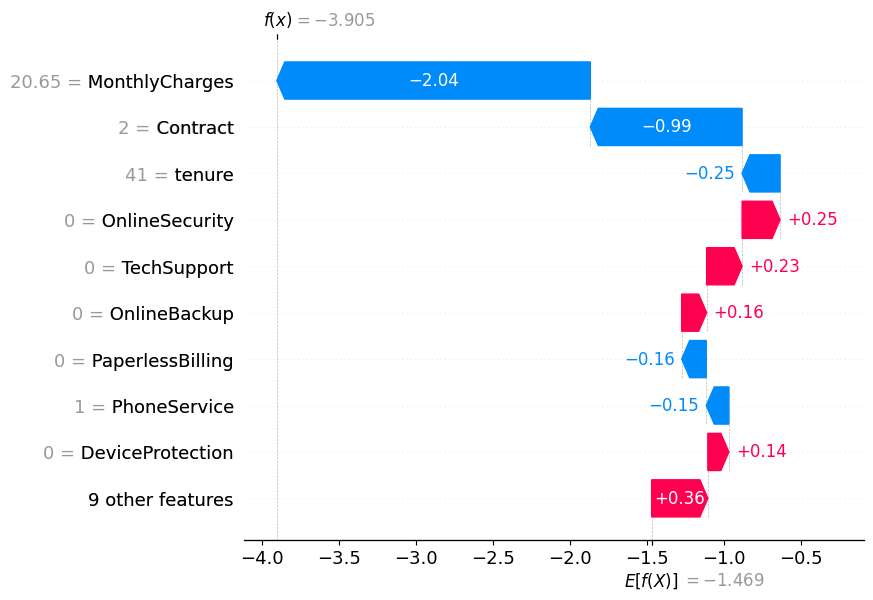

In [27]:
shap.plots.waterfall(shap_values[0])

-  `MonthlyCharges` and `Contract` are the strongest factors reducing the final prediction score.  
- A low monthly charge and 2-year contract typically indicate a highly loyal, low-churn-risk customer. 
- A high tenure of 41 months decreases the prediction score by -0.31, showing that long-term customers heavily pull the prediction downward.
- `OnlineSecurity`, `TechSupport`, and `OnlineBackup` are the top factors pushing the prediction score up. This highlights that customers without these features generally have a higher risk to churn. 